In [2]:
import pandas as pd
import ast # 用于把字符串 "{'A':1}" 转换成字典

In [3]:
# 1. 读取数据
path = '../data/raw/'
df = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
scp_statements = pd.read_csv(path + 'scp_statements.csv', index_col=0)

In [5]:
# 2. 解析 scp_codes 列
# 原始数据里 scp_codes 是字符串，需要把它变成真正的字典
df['scp_codes'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x))

In [6]:
# 3. 把代码转换成文本描述 (这是为了模拟医生的诊断文本)
# 比如把 'AMI' 翻译成 'Acute myocardial infarction'
def resolve_diagnosis(scp_dict):
    descriptions = []
    for code in scp_dict.keys():
        # 如果代码在字典里，且置信度(likelihood) > 0
        if code in scp_statements.index:
            desc = scp_statements.loc[code, 'description']
            descriptions.append(desc)
    return ", ".join(descriptions)
df['report_text'] = df['scp_codes'].apply(resolve_diagnosis)

In [7]:
# 看看长什么样
print("总数据量:", len(df))
print(df[['report_text']].head())

总数据量: 21837
                                              report_text
ecg_id                                                   
1       normal ECG, low QRS voltages in the frontal an...
2                           normal ECG, sinus bradycardia
3                                normal ECG, sinus rhythm
4                                normal ECG, sinus rhythm
5                                normal ECG, sinus rhythm


In [8]:
# 1. 定义更全面的关键词列表 (涵盖心律、心肌、传导三大类)
keywords = [
    'infarction',   # 梗死
    'ischemia',     # 缺血
    'fibrillation', # 房颤/室颤
    'flutter',      # 扑动
    'block',        # 传导阻滞 (如房室传导阻滞)
    'hypertrophy',  # 肥大
    'ST-T'          # ST-T改变 (虽然笼统，但非常常见)
]

In [9]:
# 2. 筛选：只要报告里包含以上任意一个词，就留下来
# str.contains 用法说明: case=False 表示不区分大小写
filter_condition = df['report_text'].str.contains('|'.join(keywords), case=False, na=False)

In [10]:
# 3. 额外过滤：可以明确排除掉包含 "normal ECG" 的单纯正常报告
# (即便有些正常报告可能包含 keywords 里的词，比如 'No sign of infarction'，我们暂时先保留，靠后续大模型去识别否定词)
filtered_df = df[filter_condition].copy()

In [12]:
print(f"原始数据量: {len(df)}")
print(f"筛选后的高价值病理数据量: {len(filtered_df)}")

# 看看现在的样本
print("\n=== 筛选后的样本预览 ===")
for i in range(10):
    print(f"样本 {i+1}: {filtered_df['report_text'].iloc[i]}")

原始数据量: 21837
筛选后的高价值病理数据量: 10354

=== 筛选后的样本预览 ===
样本 1: inferior myocardial infarction, abnormal QRS, sinus rhythm
样本 2: atrial flutter, abnormal QRS, atrial fibrillation
样本 3: atrial flutter
样本 4: atrial flutter, abnormal QRS
样本 5: atrial flutter
样本 6: left ventricular hypertrophy, sinus rhythm
样本 7: left posterior fascicular block, sinus rhythm
样本 8: atrial flutter
样本 9: inferior myocardial infarction, long QT-interval, non-specific ST changes, digitalis-effect, abnormal QRS, sinus rhythm
样本 10: left anterior fascicular block, sinus rhythm


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [27]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# 这一步是为了找到系统里真实存在的字体
import matplotlib.font_manager
print([f.name for f in matplotlib.font_manager.fontManager.ttflist if 'Hei' in f.name or 'Song' in f.name])

['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']


In [28]:
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

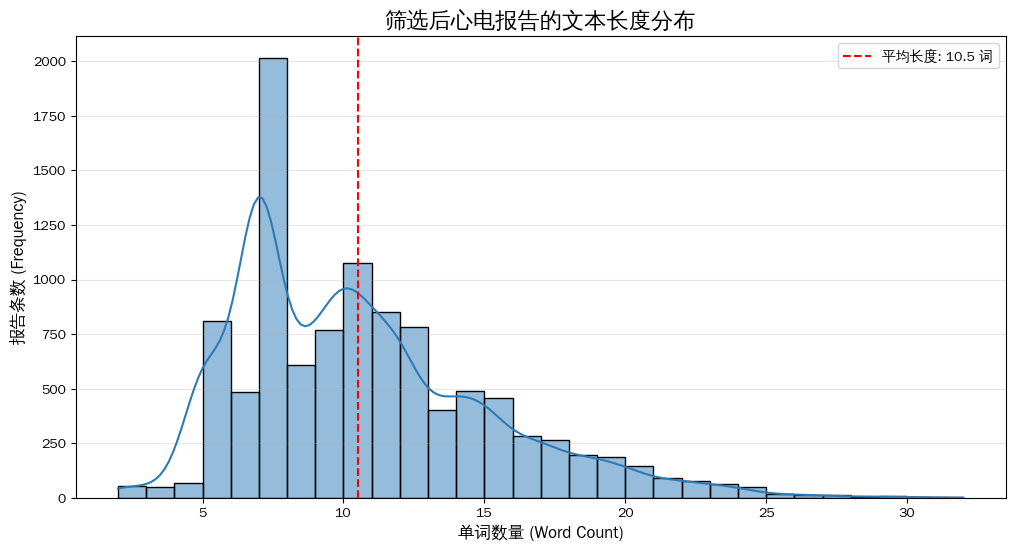

In [29]:
# === 绘图代码 ===
# 计算单词数量
filtered_df['word_count'] = filtered_df['report_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(12, 6))
# 绘制直方图
sns.histplot(filtered_df['word_count'], bins=30, kde=True, color='#2c7bb6')
plt.title('筛选后心电报告的文本长度分布', fontsize=16)
plt.xlabel('单词数量 (Word Count)', fontsize=12)
plt.ylabel('报告条数 (Frequency)', fontsize=12)

# 添加平均线
mean_len = filtered_df['word_count'].mean()
plt.axvline(mean_len, color='red', linestyle='--', label=f'平均长度: {mean_len:.1f} 词')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [30]:
# === 保存文件 ===
save_path = '../data/processed/'
os.makedirs(save_path, exist_ok=True)
# 1. 保存全量备份 (以防万一)
filtered_df.to_csv(save_path + 'filtered_all.csv')

# 2. 【关键】生成“金标准候选集” (Gold Candidates)
# 也就是亲自去标注的 50 条“考试题”
# 挑一点“长”的，因为短的太简单了，没挑战性
long_samples = filtered_df[filtered_df['word_count'] > 5] # 只要大于5个词的
gold_candidates = long_samples.sample(n=50, random_state=42)
gold_candidates[['report_text']].to_csv(save_path + 'gold_candidates.csv')
print(f"已生成金标准候选集: {save_path}gold_candidates.csv")

# 3. 【关键】生成“待蒸馏数据集” (Unlabeled Data)
# 这是给大模型跑的数据。为了节省成本和时间，先取 2000 条
# 把选作金标准的那 50 条剔除掉，防止“考试题泄露”到“训练集”里
remaining_data = filtered_df.drop(gold_candidates.index)
unlabeled_data = remaining_data.sample(n=2000, random_state=42)
unlabeled_data[['report_text']].to_csv(save_path + 'to_be_distilled.csv')
print(f"已生成待蒸馏数据集: {save_path}to_be_distilled.csv")

print("\nWeek 1 任务圆满完成！")

已生成金标准候选集: ../data/processed/gold_candidates.csv
已生成待蒸馏数据集: ../data/processed/to_be_distilled.csv

Week 1 任务圆满完成！
